In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Setup ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")

intakes_df = pd.read_csv(r"D:\Downloads\austin_intakes.csv")
outcomes_df = pd.read_csv(r"D:\Downloads\austin_outcomes.csv")

In [2]:
# ── Parsing ────────────────────────────────────────────────────────────────────
date_cols_intakes = ["source_date", "date_of_birth", "timestamp"]
date_cols_outcomes = ["outcome_date", "intake_date", "date_of_birth", "timestamp"]

for col in date_cols_intakes:
    intakes_df[col] = pd.to_datetime(intakes_df[col], errors="coerce")

for col in date_cols_outcomes:
    outcomes_df[col] = pd.to_datetime(outcomes_df[col], errors="coerce")

outcomes_df["days_in_shelter"] = pd.to_numeric(outcomes_df["days_in_shelter"], errors="coerce")

# Derive age at intake in years
intakes_df["age_at_intake"] = (
    intakes_df["source_date"] - intakes_df["date_of_birth"]
).dt.days / 365.25

intakes_df["intake_year"] = intakes_df["source_date"].dt.year
intakes_df["type_grouped"] = intakes_df["type"].apply(
    lambda x: x if x in ["Dog", "Cat"] else "Other"
)

## INTAKES

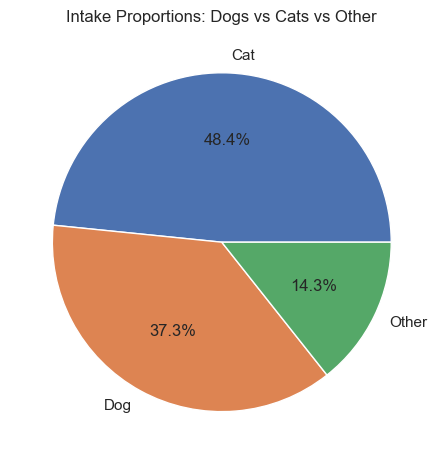

In [3]:
# 1. Animal type proportions
fig, ax = plt.subplots()
intakes_df["type_grouped"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax)
ax.set_title("Intake Proportions: Dogs vs Cats vs Other")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_01_type_proportions.png")
plt.show()
plt.close()

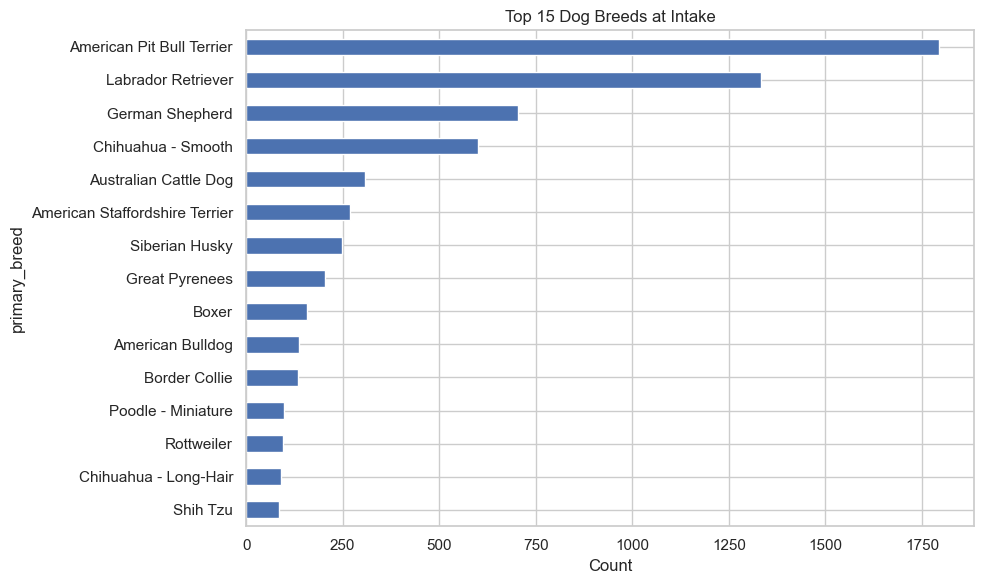

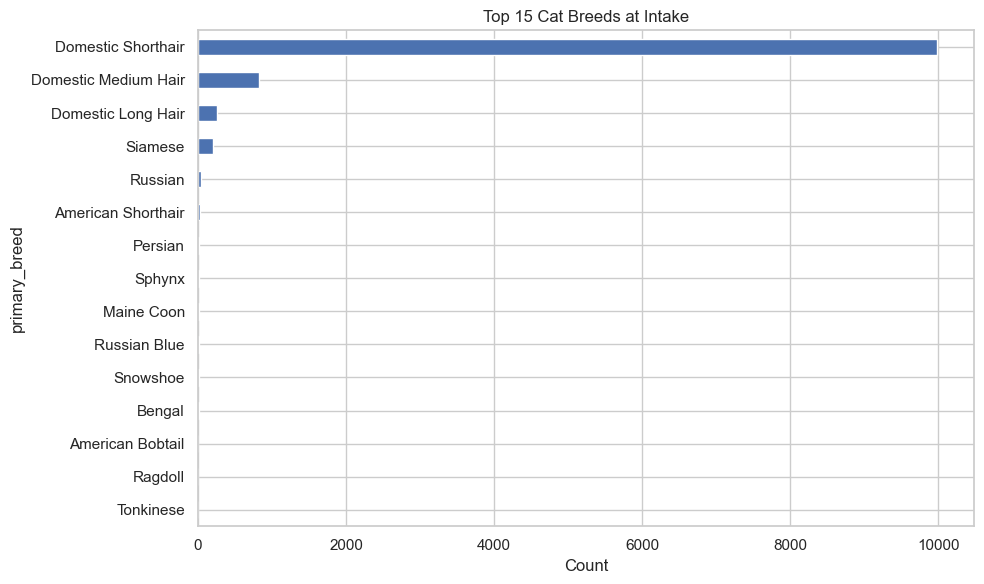

In [4]:
# 2. Top breeds by type
for animal_type in ["Dog", "Cat"]:
    subset = intakes_df[intakes_df["type"] == animal_type]
    top_breeds = (
        subset["primary_breed"]
        .str.strip()
        .str.title()
        .value_counts()
        .head(15)
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    top_breeds.sort_values().plot.barh(ax=ax)
    ax.set_title(f"Top 15 {animal_type} Breeds at Intake")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig(f"D:\\Downloads\\eda_02_top_breeds_{animal_type.lower()}.png")
    plt.show()
    plt.close()

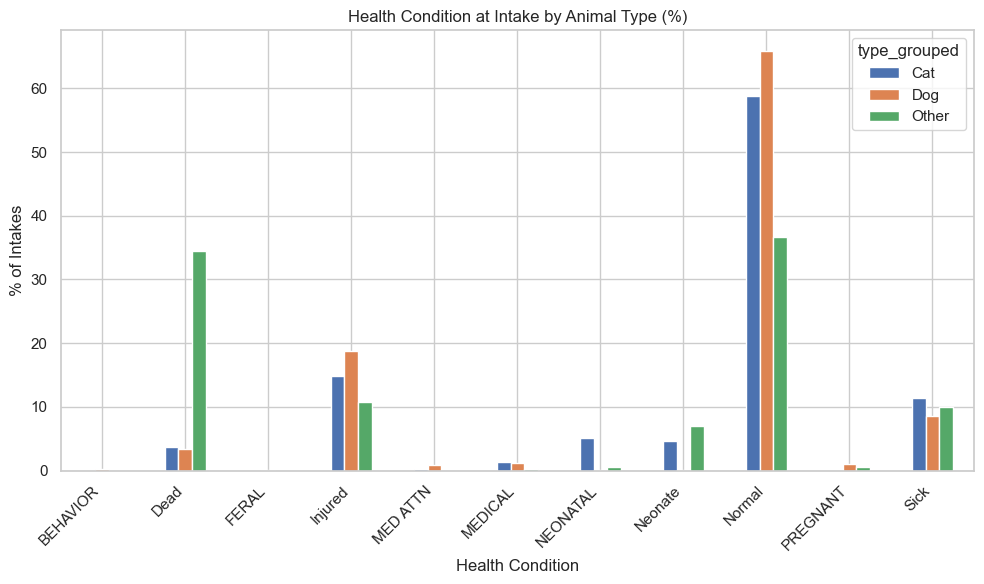

In [5]:
# 3. Health condition at intake by animal type
health_by_type = (
    intakes_df.groupby(["type_grouped", "intake_health_condition"])
    .size()
    .reset_index(name="count")
)
health_pivot = health_by_type.pivot(
    index="intake_health_condition", columns="type_grouped", values="count"
).fillna(0)
health_pivot_pct = health_pivot.div(health_pivot.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 6))
health_pivot_pct.plot.bar(ax=ax)
ax.set_title("Health Condition at Intake by Animal Type (%)")
ax.set_xlabel("Health Condition")
ax.set_ylabel("% of Intakes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_03_health_condition.png")
plt.show()
plt.close()

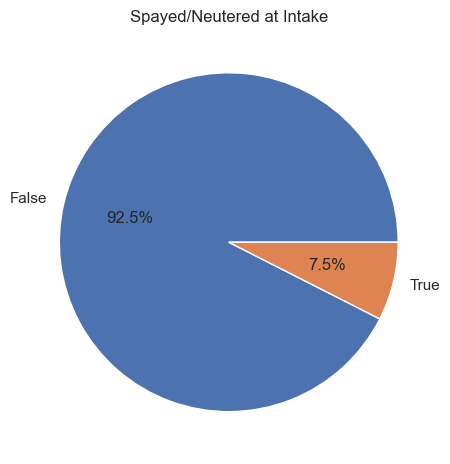

In [6]:
# 4. Spay/neuter status
fig, ax = plt.subplots()
intakes_df["ispreviouslyspayedneutered"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax)
ax.set_title("Spayed/Neutered at Intake")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_04_spay_neuter.png")
plt.show()
plt.close()

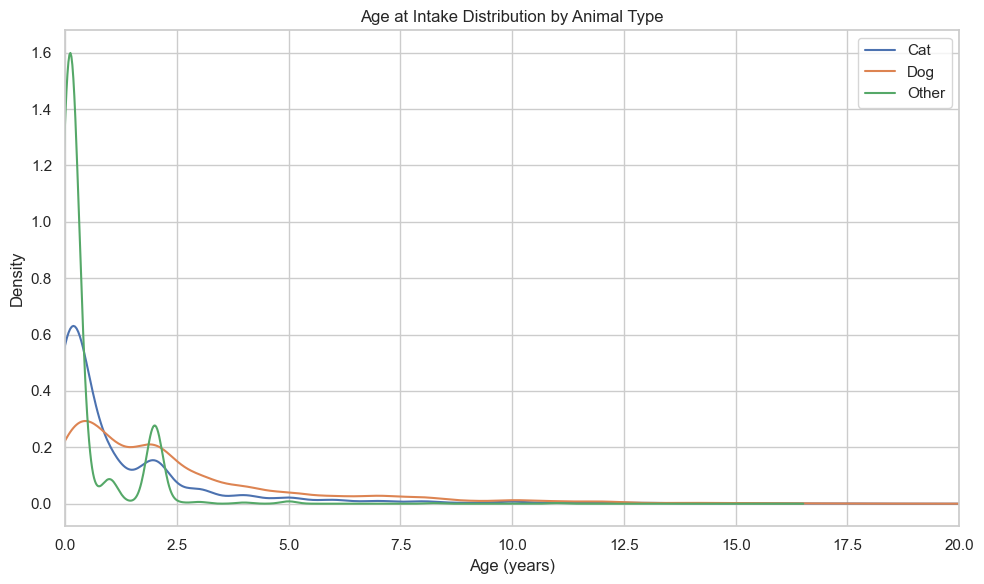

In [7]:
# 5. Age distribution by animal type
fig, ax = plt.subplots(figsize=(10, 6))
for animal_type, group in intakes_df.groupby("type_grouped"):
    group["age_at_intake"].dropna().plot.kde(ax=ax, label=animal_type)
ax.set_title("Age at Intake Distribution by Animal Type")
ax.set_xlabel("Age (years)")
ax.set_xlim(0, 20)
ax.legend()
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_05_age_distribution.png")
plt.show()
plt.close()

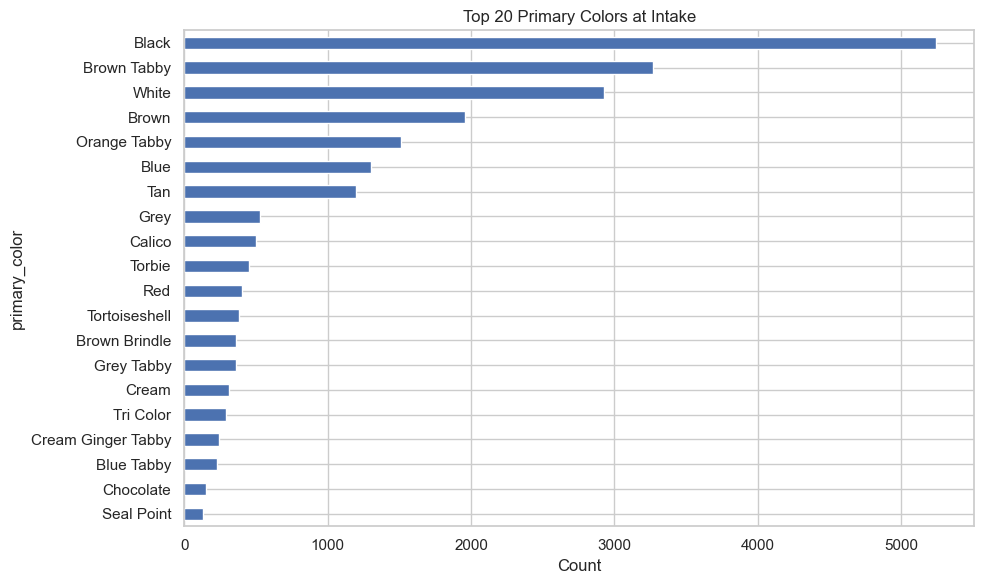

In [8]:
# 6. Primary color frequency
top_colors = intakes_df["primary_color"].str.strip().str.title().value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_colors.sort_values().plot.barh(ax=ax)
ax.set_title("Top 20 Primary Colors at Intake")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_06_colors.png")
plt.show()
plt.close()

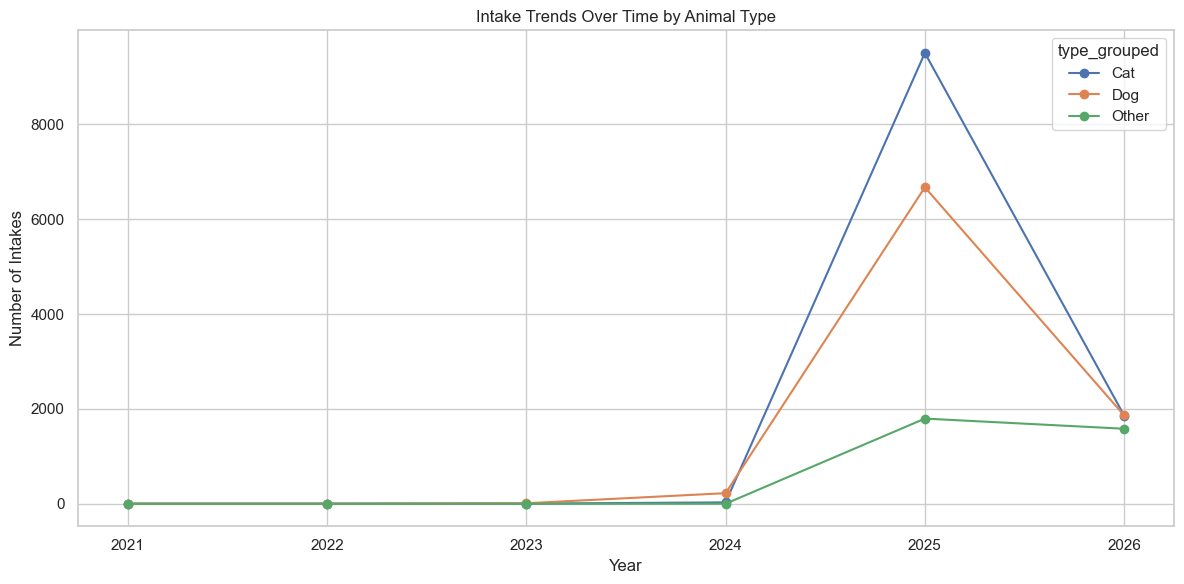

In [9]:
# 7. Intake trends over the years
yearly = intakes_df.groupby(["intake_year", "type_grouped"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
yearly.plot(ax=ax, marker="o")
ax.set_title("Intake Trends Over Time by Animal Type")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Intakes")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_07_yearly_trends.png")
plt.show()
plt.close()

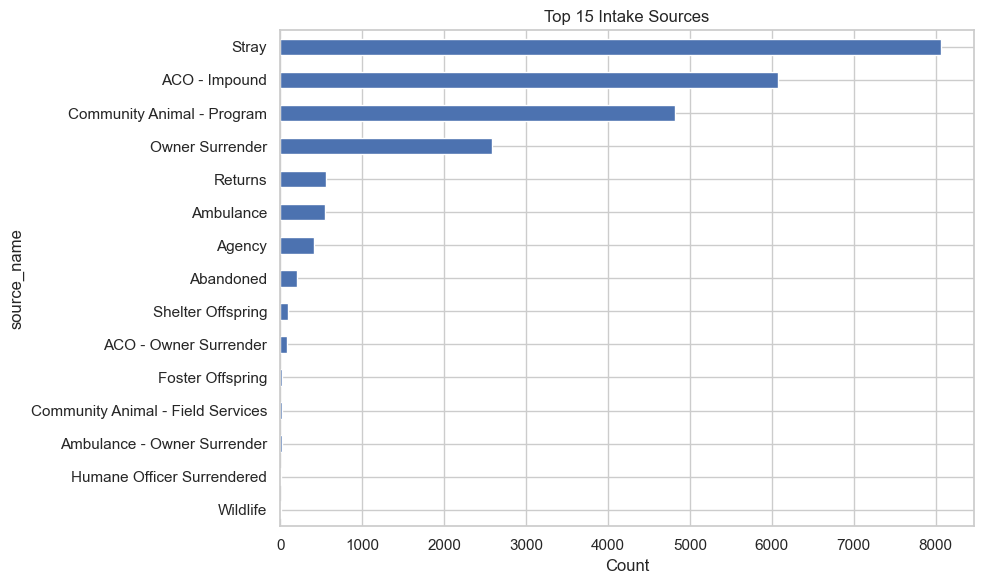

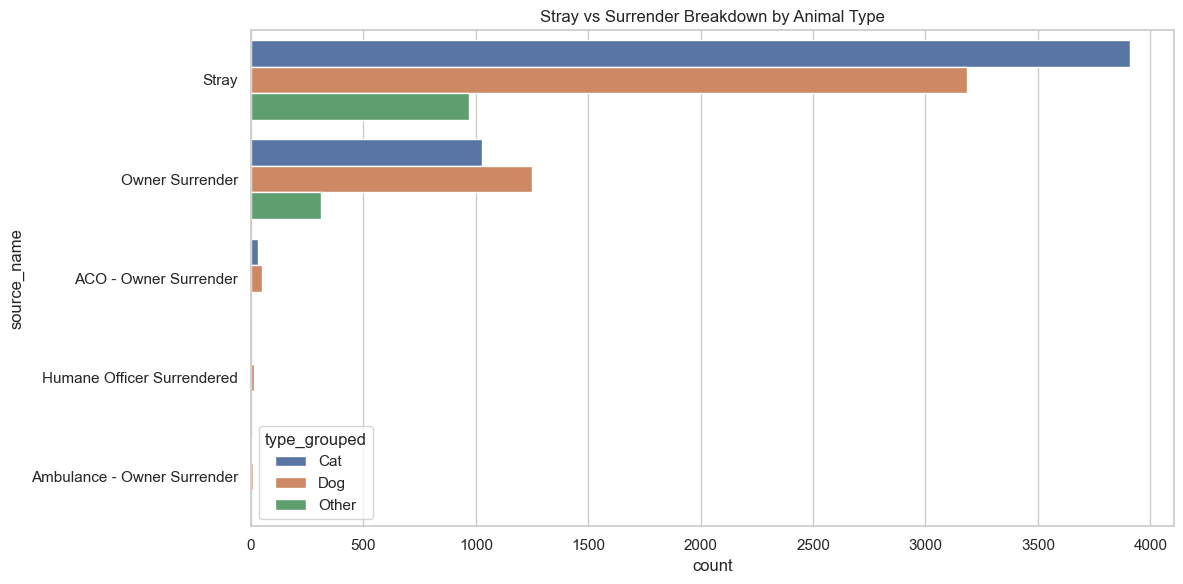

In [10]:
# 8. Intake source analysis
top_sources = intakes_df["source_name"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_sources.sort_values().plot.barh(ax=ax)
ax.set_title("Top 15 Intake Sources")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_08_intake_sources.png")
plt.show()
plt.close()

# Stray vs surrender breakdown by type
stray_surrender = intakes_df[
    intakes_df["source_name"].str.contains("Stray|Surrender", case=False, na=False)
]
stray_surrender_breakdown = (
    stray_surrender.groupby(["source_name", "type_grouped"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=stray_surrender_breakdown, x="count", y="source_name", hue="type_grouped", ax=ax)
ax.set_title("Stray vs Surrender Breakdown by Animal Type")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_08b_stray_surrender.png")
plt.show()
plt.close()

## OUTCOMES

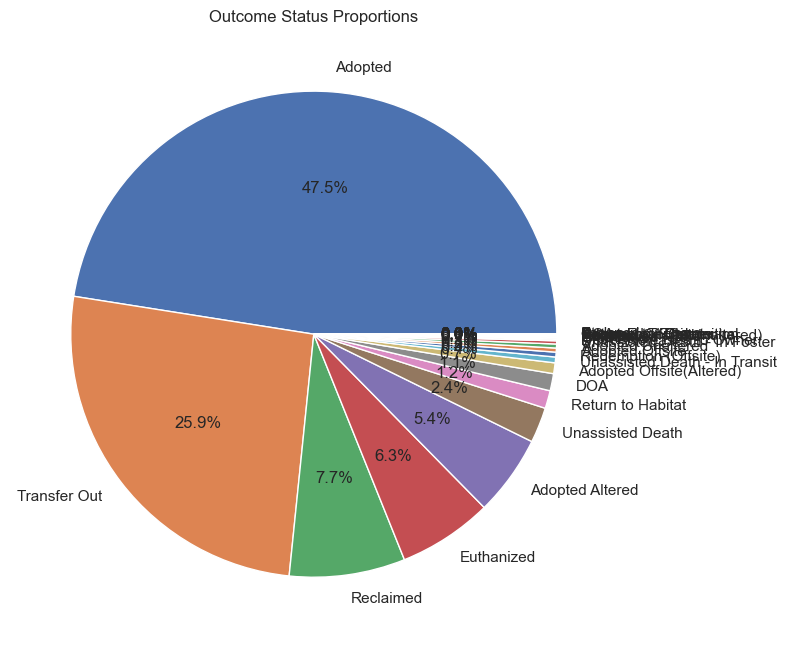

In [11]:
# 9. Outcome status proportions
fig, ax = plt.subplots(figsize=(8, 8))
outcomes_df["outcome_status"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax)
ax.set_title("Outcome Status Proportions")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_09_outcome_status.png")
plt.show()
plt.close()

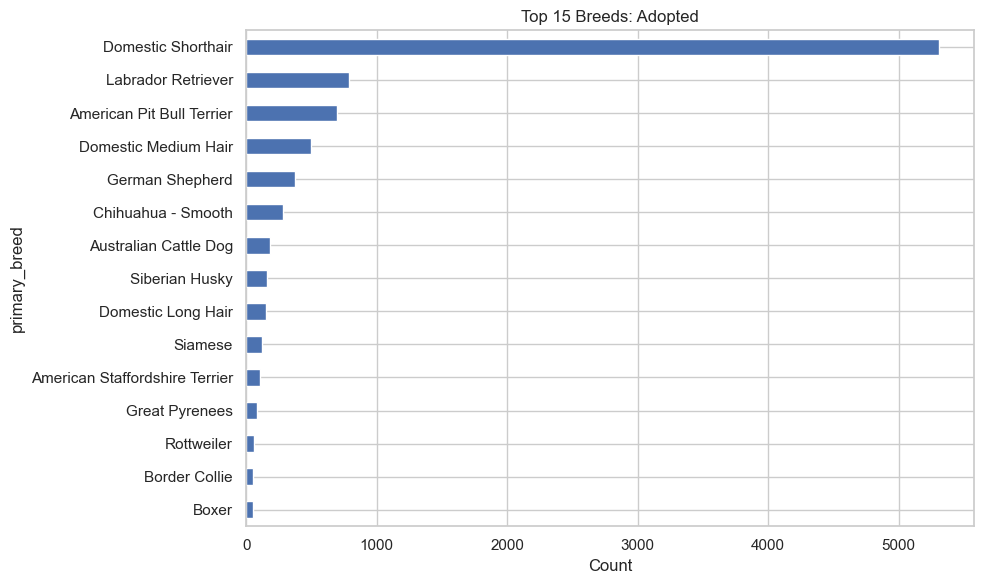

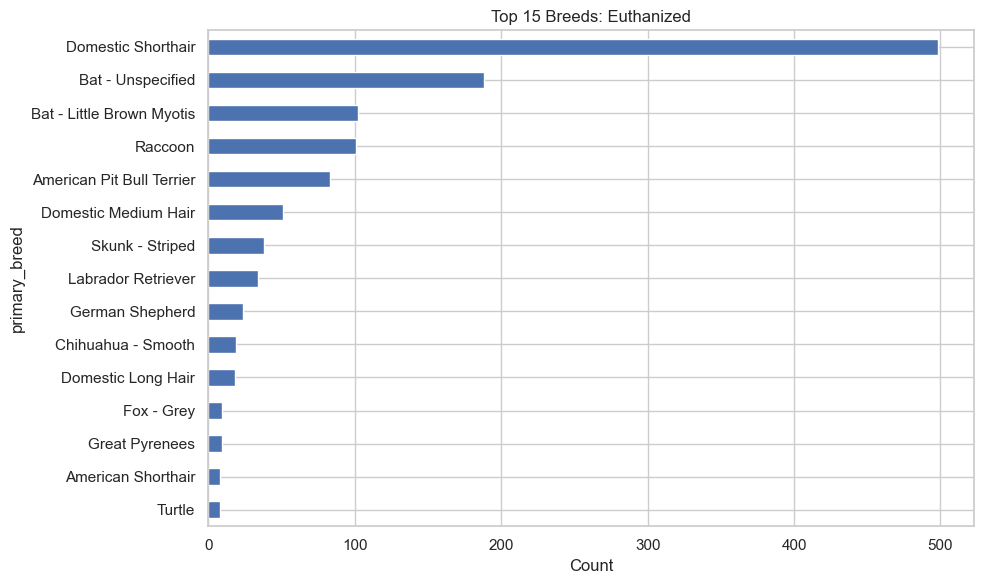

In [16]:
# 10. Adoption and euthanasia counts by breed (top breeds only)
for outcome, label in [("Adopted", "adoption"), ("Euthanized", "euthanasia")]:
    subset = outcomes_df[outcomes_df["outcome_status"] == outcome]
    top = subset["primary_breed"].str.strip().str.title().value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    top.sort_values().plot.barh(ax=ax)
    ax.set_title(f"Top 15 Breeds: {outcome}")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig(f"D:\\Downloads\\eda_10_{label}_by_breed.png")
    plt.show()
    plt.close()

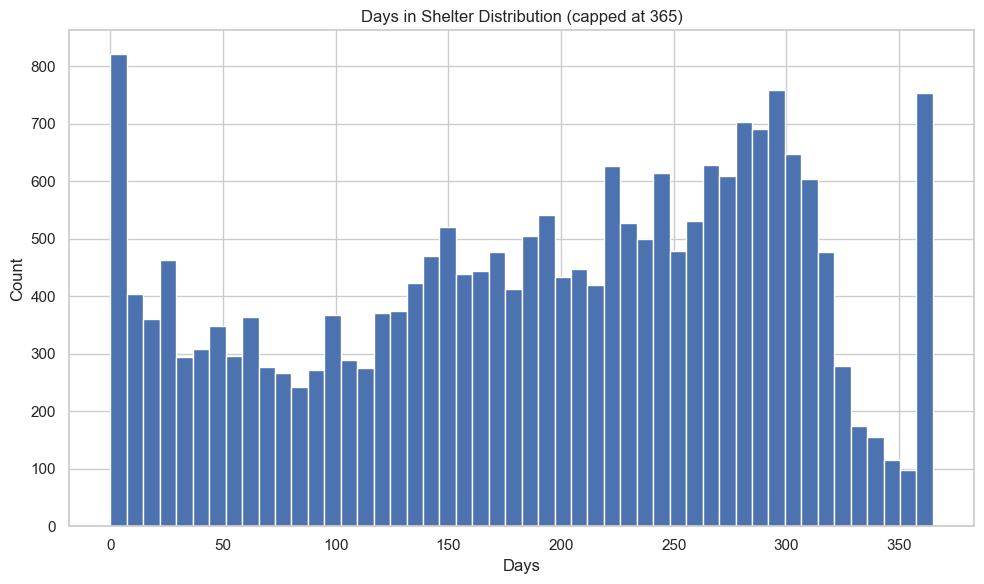

Median days in shelter: 202.0
Mean days in shelter: 194.1


In [14]:
# 11. Days in shelter distribution
fig, ax = plt.subplots(figsize=(10, 6))
outcomes_df["days_in_shelter"].clip(upper=365).plot.hist(bins=50, ax=ax)
ax.set_title("Days in Shelter Distribution (capped at 365)")
ax.set_xlabel("Days")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_11_days_in_shelter.png")
plt.show()
plt.close()

print(f"Median days in shelter: {outcomes_df['days_in_shelter'].median():.1f}")
print(f"Mean days in shelter: {outcomes_df['days_in_shelter'].mean():.1f}")

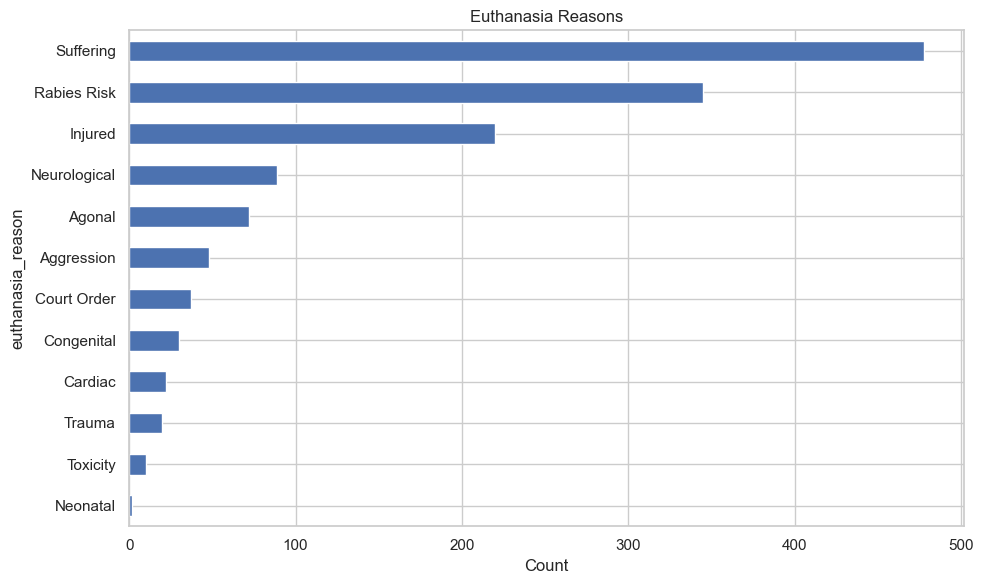

In [18]:
# 12. Euthanasia reasons
euth = outcomes_df[outcomes_df["outcome_status"] == "Euthanized"]
euth_reasons = euth["euthanasia_reason"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
euth_reasons.sort_values().plot.barh(ax=ax)
ax.set_title("Euthanasia Reasons")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_12_euthanasia_reasons.png")
plt.show()
plt.close()

## JOINED ANALYSIS (Intakes + Outcomes)
Join on animal_id to connect intake characteristics to outcomes.

In [19]:
# ── Helper: simplify outcome status ───────────────────────────────────────────
def simplify_outcome(s):
    if pd.isna(s): return 'Other'
    s = s.lower()
    if 'adopt' in s: return 'Adopted'
    if 'euthan' in s: return 'Euthanized'
    if 'transfer' in s: return 'Transferred'
    if 'reclaim' in s or 'redemption' in s or 'returned to owner' in s: return 'Reclaimed'
    if 'death' in s or 'doa' in s or 'died' in s: return 'Died'
    if 'habitat' in s: return 'Return to Habitat'
    return 'Other'

def normalize_type(t):
    if pd.isna(t): return 'Other'
    t = t.lower()
    if 'cat' in t or 'kitten' in t: return 'Cat'
    if 'dog' in t or 'puppy' in t: return 'Dog'
    return 'Other'

outcomes_df['outcome_simple'] = outcomes_df['outcome_status'].apply(simplify_outcome)
outcomes_df['type_grouped'] = outcomes_df['type'].apply(normalize_type)

# Take most recent intake per animal to avoid fan-out on join
latest_intake = (
    intakes_df.sort_values('source_date')
    .groupby('animal_id')
    .last()
    .reset_index()
)

merged = outcomes_df.merge(
    latest_intake[['animal_id', 'source_name', 'intake_health_condition', 'age_at_intake', 'ispreviouslyspayedneutered']],
    on='animal_id',
    how='left'
)

print(f"Merged rows: {len(merged):,}")
print(merged['outcome_simple'].value_counts())

Merged rows: 21,890
outcome_simple
Adopted              11855
Transferred           5664
Reclaimed             1760
Euthanized            1383
Died                   918
Return to Habitat      260
Other                   50
Name: count, dtype: int64


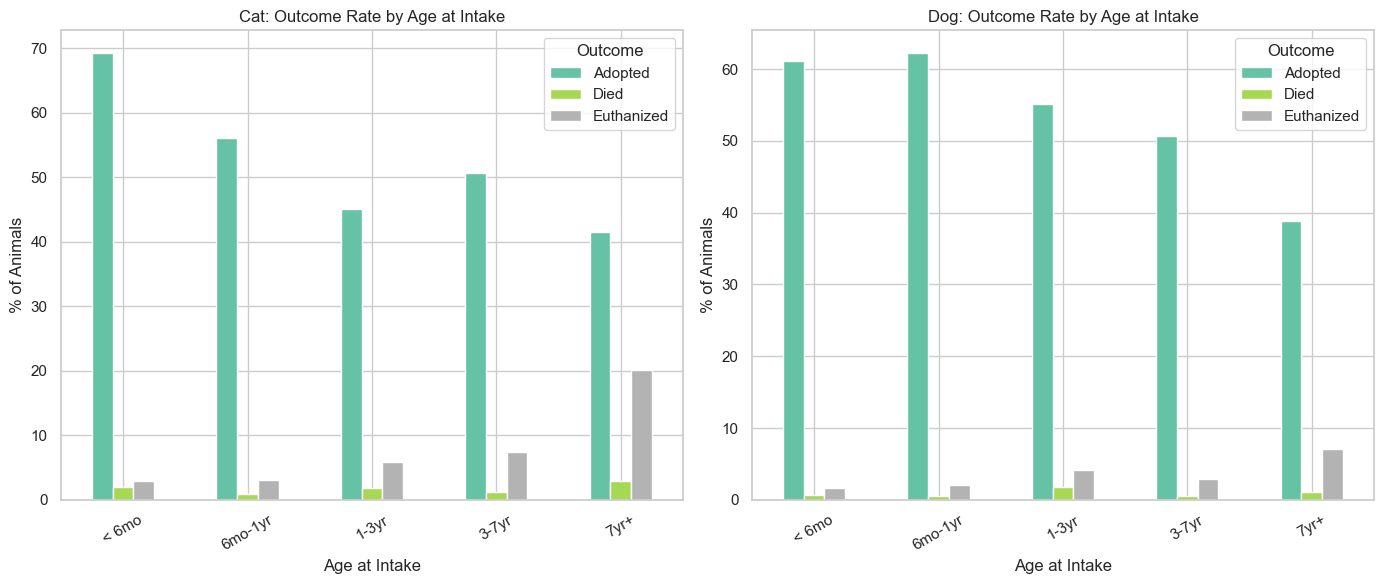

In [20]:
# 13. Outcome rate by age bucket (Cat and Dog separately)
merged['age_bucket'] = pd.cut(
    merged['age_at_intake'],
    bins=[0, 0.5, 1, 3, 7, 100],
    labels=['< 6mo', '6mo-1yr', '1-3yr', '3-7yr', '7yr+']
)

age_outcome = (
    merged[merged['type_grouped'].isin(['Cat', 'Dog'])]
    .groupby(['type_grouped', 'age_bucket', 'outcome_simple'])
    .size()
    .reset_index(name='count')
)
age_total = age_outcome.groupby(['type_grouped', 'age_bucket'])['count'].transform('sum')
age_outcome['pct'] = age_outcome['count'] / age_total * 100
focus = age_outcome[age_outcome['outcome_simple'].isin(['Adopted', 'Euthanized', 'Died'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
for ax, animal in zip(axes, ['Cat', 'Dog']):
    subset = focus[focus['type_grouped'] == animal]
    pivot = subset.pivot_table(index='age_bucket', columns='outcome_simple', values='pct', fill_value=0)
    pivot.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'{animal}: Outcome Rate by Age at Intake')
    ax.set_xlabel('Age at Intake')
    ax.set_ylabel('% of Animals')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Outcome')

plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_13_outcome_by_age.png")
plt.show()
plt.close()

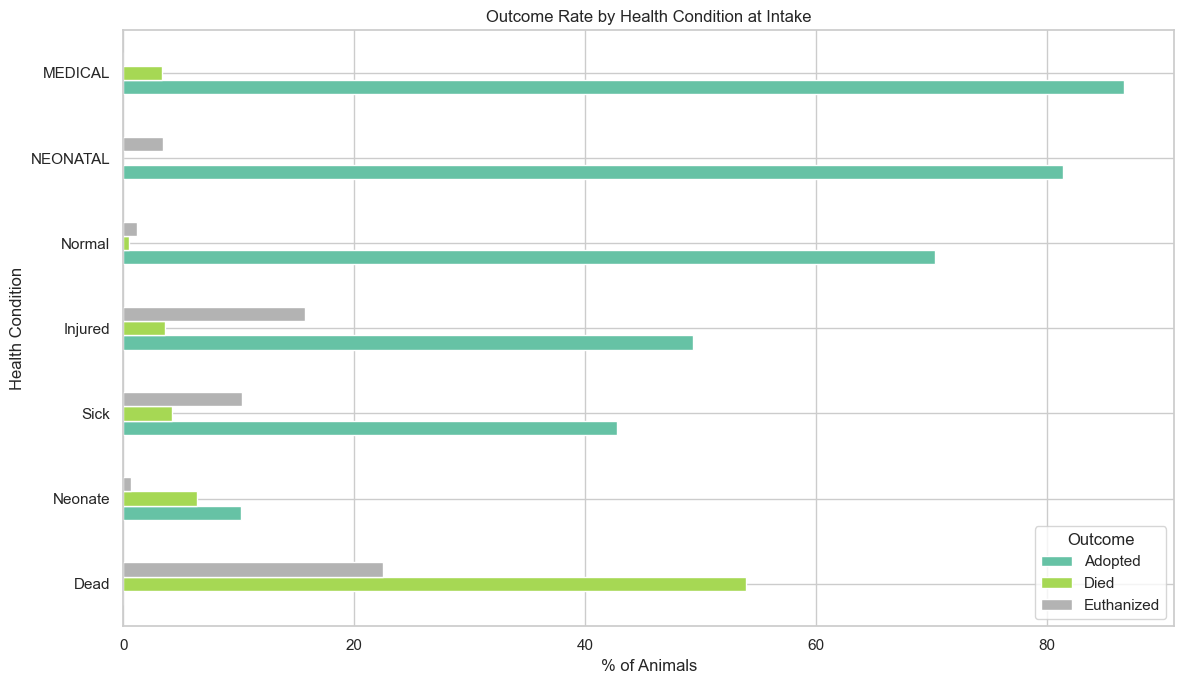

In [21]:
# 14. Outcome rate by health condition at intake
health_outcome = (
    merged[merged['type_grouped'].isin(['Cat', 'Dog'])]
    .groupby(['intake_health_condition', 'outcome_simple'])
    .size()
    .reset_index(name='count')
)
health_total = health_outcome.groupby('intake_health_condition')['count'].transform('sum')
health_outcome['pct'] = health_outcome['count'] / health_total * 100

# Only keep conditions with 50+ records
condition_counts = merged['intake_health_condition'].value_counts()
valid_conditions = condition_counts[condition_counts > 50].index
health_focus = health_outcome[
    (health_outcome['intake_health_condition'].isin(valid_conditions)) &
    (health_outcome['outcome_simple'].isin(['Adopted', 'Euthanized', 'Died']))
]

pivot_h = health_focus.pivot_table(index='intake_health_condition', columns='outcome_simple', values='pct', fill_value=0)
pivot_h = pivot_h.sort_values('Adopted', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
pivot_h.plot(kind='barh', ax=ax, colormap='Set2')
ax.set_title('Outcome Rate by Health Condition at Intake')
ax.set_xlabel('% of Animals')
ax.set_ylabel('Health Condition')
ax.legend(title='Outcome')
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_14_outcome_by_health.png")
plt.show()
plt.close()

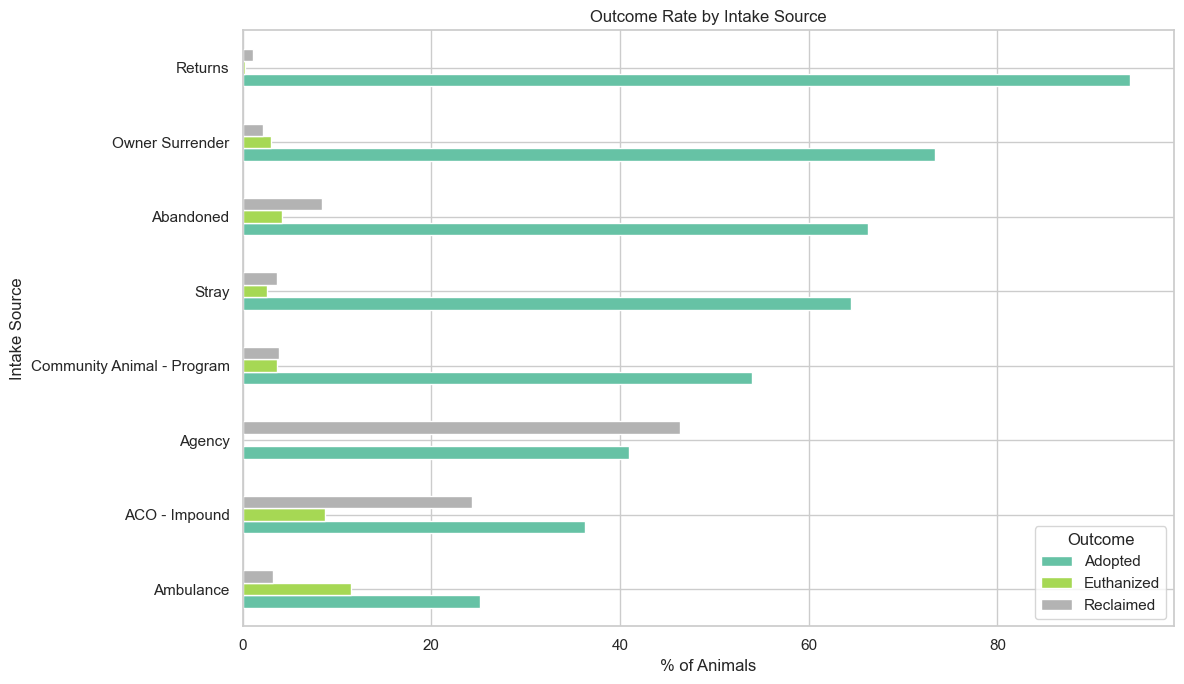

In [22]:
# 15. Outcome rate by intake source
source_outcome = (
    merged[merged['type_grouped'].isin(['Cat', 'Dog'])]
    .groupby(['source_name', 'outcome_simple'])
    .size()
    .reset_index(name='count')
)
source_total = source_outcome.groupby('source_name')['count'].transform('sum')
source_outcome['pct'] = source_outcome['count'] / source_total * 100

# Only keep sources with 100+ records
source_counts = merged['source_name'].value_counts()
valid_sources = source_counts[source_counts > 100].index
source_focus = source_outcome[
    (source_outcome['source_name'].isin(valid_sources)) &
    (source_outcome['outcome_simple'].isin(['Adopted', 'Euthanized', 'Reclaimed']))
]

pivot_s = source_focus.pivot_table(index='source_name', columns='outcome_simple', values='pct', fill_value=0)
pivot_s = pivot_s.sort_values('Adopted', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
pivot_s.plot(kind='barh', ax=ax, colormap='Set2')
ax.set_title('Outcome Rate by Intake Source')
ax.set_xlabel('% of Animals')
ax.set_ylabel('Intake Source')
ax.legend(title='Outcome')
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_15_outcome_by_source.png")
plt.show()
plt.close()

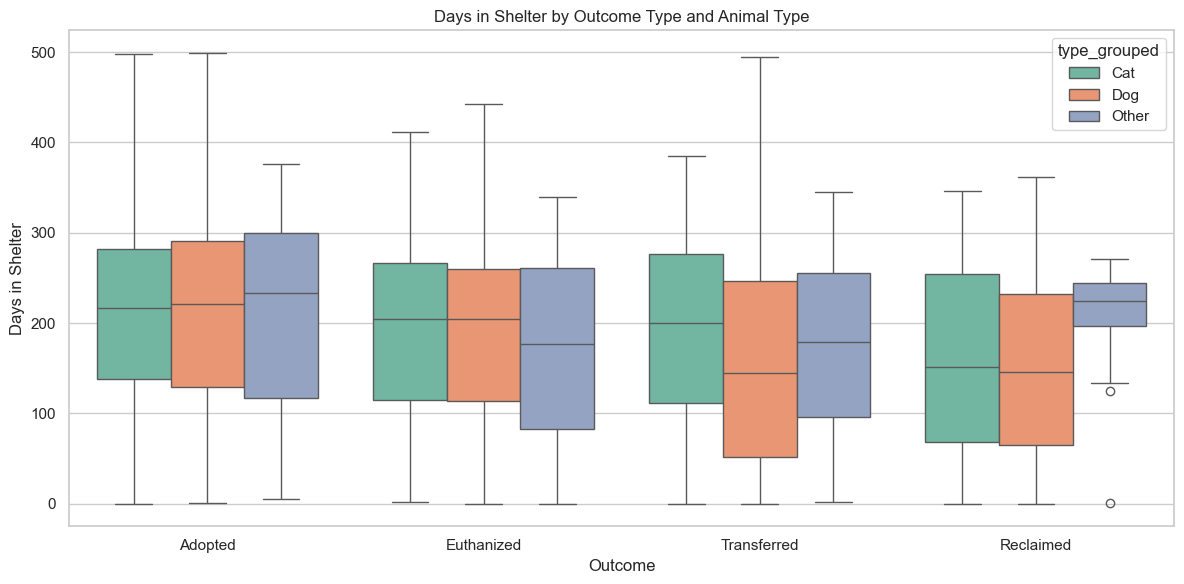

In [23]:
# 16. Days in shelter by outcome type (boxplot)
shelter_focus = merged[
    (merged['outcome_simple'].isin(['Adopted', 'Euthanized', 'Transferred', 'Reclaimed'])) &
    (merged['days_in_shelter'].notna()) &
    (merged['days_in_shelter'] < 500)
]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=shelter_focus,
    x='outcome_simple',
    y='days_in_shelter',
    hue='type_grouped',
    palette='Set2',
    ax=ax,
    order=['Adopted', 'Euthanized', 'Transferred', 'Reclaimed']
)
ax.set_title('Days in Shelter by Outcome Type and Animal Type')
ax.set_xlabel('Outcome')
ax.set_ylabel('Days in Shelter')
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_16_days_by_outcome.png")
plt.show()
plt.close()

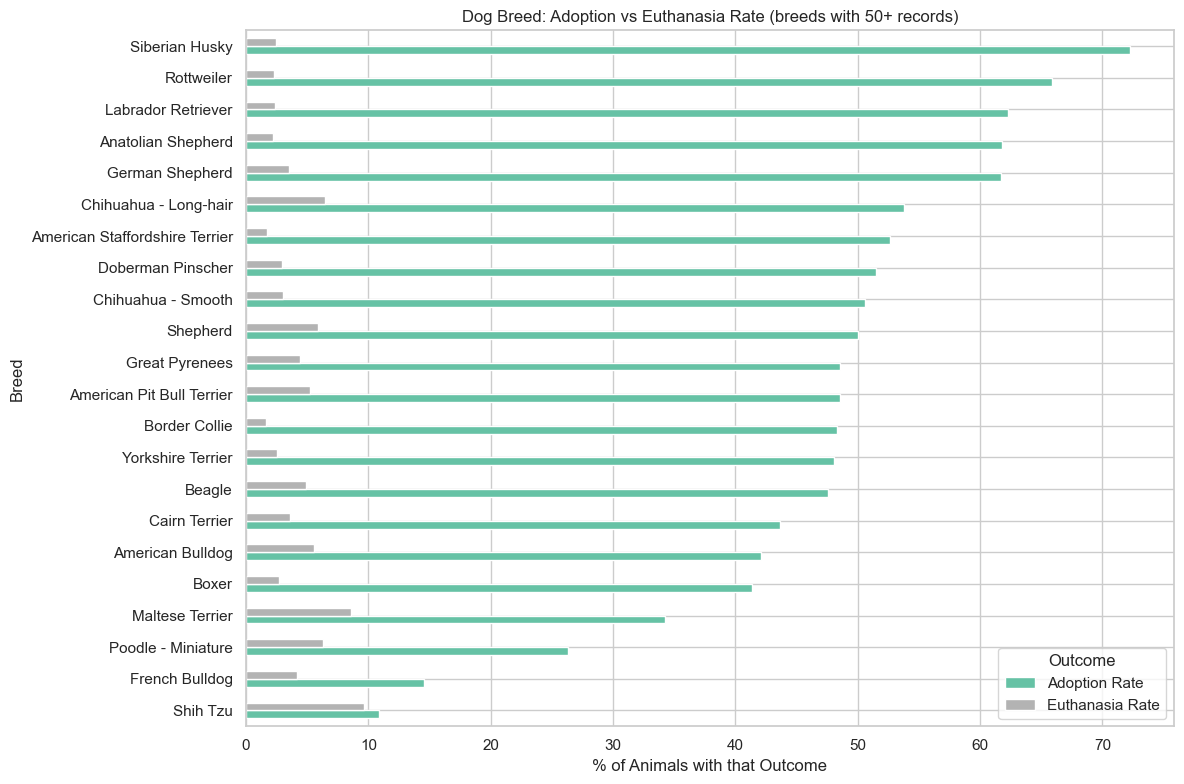

EDA V3 complete. All charts saved to D:\Downloads\


In [24]:
# 17. Dog breed adoption vs euthanasia RATE (breeds with 50+ records)
dog_outcomes = merged[merged['type_grouped'] == 'Dog'].copy()
breed_counts = dog_outcomes['primary_breed'].value_counts()
common_breeds = breed_counts[breed_counts > 50].index

dog_breed = dog_outcomes[dog_outcomes['primary_breed'].isin(common_breeds)]
breed_outcome = (
    dog_breed.groupby(['primary_breed', 'outcome_simple'])
    .size()
    .reset_index(name='count')
)
breed_total = breed_outcome.groupby('primary_breed')['count'].transform('sum')
breed_outcome['pct'] = breed_outcome['count'] / breed_total * 100

adopt_rate = (
    breed_outcome[breed_outcome['outcome_simple'] == 'Adopted']
    .set_index('primary_breed')['pct']
)
euth_rate = (
    breed_outcome[breed_outcome['outcome_simple'] == 'Euthanized']
    .set_index('primary_breed')['pct']
)

rate_df = pd.DataFrame({'Adoption Rate': adopt_rate, 'Euthanasia Rate': euth_rate}).dropna()
rate_df = rate_df.sort_values('Adoption Rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
rate_df.plot(kind='barh', ax=ax, colormap='Set2')
ax.set_title('Dog Breed: Adoption vs Euthanasia Rate (breeds with 50+ records)')
ax.set_xlabel('% of Animals with that Outcome')
ax.set_ylabel('Breed')
ax.legend(title='Outcome')
plt.tight_layout()
plt.savefig(r"D:\Downloads\eda_17_breed_rates_dog.png")
plt.show()
plt.close()

print("EDA V3 complete. All charts saved to D:\\Downloads\\")